In [1]:
!pip install google-cloud-bigquery pandas matplotlib seaborn db-dtypes


In [2]:
from google.colab import auth
auth.authenticate_user()
print("Authenticated!")

MessageError: Error: credential propagation was unsuccessful

In [3]:
from google.colab import files
uploaded = files.upload()

Saving bigdata-proj-496610-f1ef90e451cc.json to bigdata-proj-496610-f1ef90e451cc.json


In [4]:
from google.oauth2 import service_account
from google.cloud import bigquery

# Replace with your actual filename
KEY_FILE = "bigdata-proj-496610-f1ef90e451cc.json"
PROJECT_ID = "bigdata-proj-496610"

credentials = service_account.Credentials.from_service_account_file(
    KEY_FILE,
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

client = bigquery.Client(
    credentials=credentials,
    project=PROJECT_ID
)

print("Connected to BigQuery!")

Connected to BigQuery!


In [5]:
query = """
    SELECT count(*) as total_rows
    FROM `bigdata-proj-496610.listenbrainz_dev.fact_listens`
"""
df = client.query(query).to_dataframe()
print(df)

   total_rows
0     5000000


In [6]:
query = """
    select
        a.artist_name,
        count(*) as total_listens
    from `bigdata-proj-496610.listenbrainz_dev.fact_listens` f
    left join `bigdata-proj-496610.listenbrainz_dev.dim_artist` a
        on f.artist_sk = a.artist_sk
    group by 1
    order by total_listens desc
    limit 10
"""

top_artists = client.query(query).to_dataframe()
print(top_artists)

             artist_name  total_listens
0              Metallica          26540
1  Johann Sebastian Bach          20910
2             Pink Floyd          20727
3        Nine Inch Nails          19554
4              Daft Punk          19435
5         The Black Keys          18676
6              Radiohead          16040
7           Depeche Mode          15483
8         Arctic Monkeys          15330
9            Iron Maiden          13849


In [7]:
query = """
    select
        d.listen_year,
        d.listen_month,
        count(*) as total_listens
    from `bigdata-proj-496610.listenbrainz_dev.fact_listens` f
    left join `bigdata-proj-496610.listenbrainz_dev.dim_date` d
        on f.date_sk = d.date_sk
    group by 1, 2
    order by 1, 2
"""

monthly_trends = client.query(query).to_dataframe()
print(monthly_trends)

     listen_year  listen_month  total_listens
0           2005             2           7875
1           2005             3           1547
2           2005             4           1905
3           2005             5           1363
4           2005             6           2241
..           ...           ...            ...
157         2018             3          62031
158         2018             4          56409
159         2018             5          72643
160         2018             6          92036
161         2018             7          33039

[162 rows x 3 columns]


In [8]:
query = """
    select
        t.track_name,
        a.artist_name,
        count(*) as total_listens
    from `bigdata-proj-496610.listenbrainz_dev.fact_listens` f
    left join `bigdata-proj-496610.listenbrainz_dev.dim_track` t
        on f.track_sk = t.track_sk
    left join `bigdata-proj-496610.listenbrainz_dev.dim_artist` a
        on f.artist_sk = a.artist_sk
    group by 1, 2
    order by total_listens desc
    limit 10
"""

top_tracks = client.query(query).to_dataframe()
print(top_tracks)

          track_name         artist_name  total_listens
0        夜空。feat.ハジ→                miwa           5874
1  Dead End in Tokyo  Man with a Mission           4930
2              3人の写真              Kiroro           4600
3              君だったら      Happy Birthday           3457
4  Stars in the Rain               Aimer           3235
5              柊の通学路             渡り廊下走り隊           2736
6      デイ・ドリーム・ビリーバー                下村陽子           2110
7            My Hero  Man with a Mission           1750
8             closer               Aimer           1597
9             ピノとアメリ              石崎ひゅーい           1586


In [9]:
query = """
    select
        t.track_name,
        a.artist_name,
        count(*) as total_listens
    from `bigdata-proj-496610.listenbrainz_dev.fact_listens` f
    left join `bigdata-proj-496610.listenbrainz_dev.dim_track` t
        on f.track_sk = t.track_sk
    left join `bigdata-proj-496610.listenbrainz_dev.dim_artist` a
        on f.artist_sk = a.artist_sk
    group by 1, 2
    order by total_listens desc
    limit 10
"""

top_tracks = client.query(query).to_dataframe()
print(top_tracks)

          track_name         artist_name  total_listens
0        夜空。feat.ハジ→                miwa           5874
1  Dead End in Tokyo  Man with a Mission           4930
2              3人の写真              Kiroro           4600
3              君だったら      Happy Birthday           3457
4  Stars in the Rain               Aimer           3235
5              柊の通学路             渡り廊下走り隊           2736
6      デイ・ドリーム・ビリーバー                下村陽子           2110
7            My Hero  Man with a Mission           1750
8             closer               Aimer           1597
9             ピノとアメリ              石崎ひゅーい           1586


In [10]:
query = """
    select
        d.listen_year,
        d.listen_month,
        count(*) as total_listens
    from `bigdata-proj-496610.listenbrainz_dev.fact_listens` f
    left join `bigdata-proj-496610.listenbrainz_dev.dim_date` d
        on f.date_sk = d.date_sk
    group by 1, 2
    order by 1, 2
"""

monthly_trends = client.query(query).to_dataframe()
print(monthly_trends)

     listen_year  listen_month  total_listens
0           2005             2           7875
1           2005             3           1547
2           2005             4           1905
3           2005             5           1363
4           2005             6           2241
..           ...           ...            ...
157         2018             3          62031
158         2018             4          56409
159         2018             5          72643
160         2018             6          92036
161         2018             7          33039

[162 rows x 3 columns]


In [11]:
query = """
    select
        t.track_name,
        a.artist_name,
        count(*) as total_listens
    from `bigdata-proj-496610.listenbrainz_dev.fact_listens` f
    left join `bigdata-proj-496610.listenbrainz_dev.dim_track` t
        on f.track_sk = t.track_sk
    left join `bigdata-proj-496610.listenbrainz_dev.dim_artist` a
        on f.artist_sk = a.artist_sk
    group by 1, 2
    order by total_listens desc
    limit 10
"""

top_tracks = client.query(query).to_dataframe()
print(top_tracks)

          track_name         artist_name  total_listens
0        夜空。feat.ハジ→                miwa           5874
1  Dead End in Tokyo  Man with a Mission           4930
2              3人の写真              Kiroro           4600
3              君だったら      Happy Birthday           3457
4  Stars in the Rain               Aimer           3235
5              柊の通学路             渡り廊下走り隊           2736
6      デイ・ドリーム・ビリーバー                下村陽子           2110
7            My Hero  Man with a Mission           1750
8             closer               Aimer           1597
9             ピノとアメリ              石崎ひゅーい           1586


In [12]:
query = """
    select
        u.user_name,
        count(*) as total_listens
    from `bigdata-proj-496610.listenbrainz_dev.fact_listens` f
    left join `bigdata-proj-496610.listenbrainz_dev.dim_user` u
        on f.user_sk = u.user_sk
    group by 1
    order by total_listens desc
    limit 10
"""

top_users = client.query(query).to_dataframe()
print(top_users)

  user_name  total_listens
0   tomaszg         239116
1    fareth         210785
2    luize0         180498
3     foogs         164701
4  jaivalis         164179
5   elflord         152657
6  pinoczet         143941
7    gdedas         139227
8     feest         122033
9       ngk         110342


In [13]:
query = """
    select
        d.listen_hour,
        count(*) as total_listens
    from `bigdata-proj-496610.listenbrainz_dev.fact_listens` f
    left join `bigdata-proj-496610.listenbrainz_dev.dim_date` d
        on f.date_sk = d.date_sk
    group by 1
    order by 1
"""

hourly_trends = client.query(query).to_dataframe()
print(hourly_trends)

    listen_hour  total_listens
0             0         157601
1             1         138158
2             2         128176
3             3         121991
4             4         135543
5             5         155100
6             6         165294
7             7         168492
8             8         184083
9             9         205823
10           10         226817
11           11         228036
12           12         228979
13           13         240759
14           14         257331
15           15         272142
16           16         274953
17           17         273698
18           18         268661
19           19         261581
20           20         257863
21           21         244004
22           22         220292
23           23         184623


/tmp/ipykernel_1718/1997241052.py:111: UserWarning: Glyph 22812 (\N{CJK UNIFIED IDEOGRAPH-591C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1718/1997241052.py:111: UserWarning: Glyph 31354 (\N{CJK UNIFIED IDEOGRAPH-7A7A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1718/1997241052.py:111: UserWarning: Glyph 12290 (\N{IDEOGRAPHIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1718/1997241052.py:111: UserWarning: Glyph 12495 (\N{KATAKANA LETTER HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1718/1997241052.py:111: UserWarning: Glyph 12472 (\N{KATAKANA LETTER ZI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1718/1997241052.py:111: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1718/1997241052.py:111: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s)

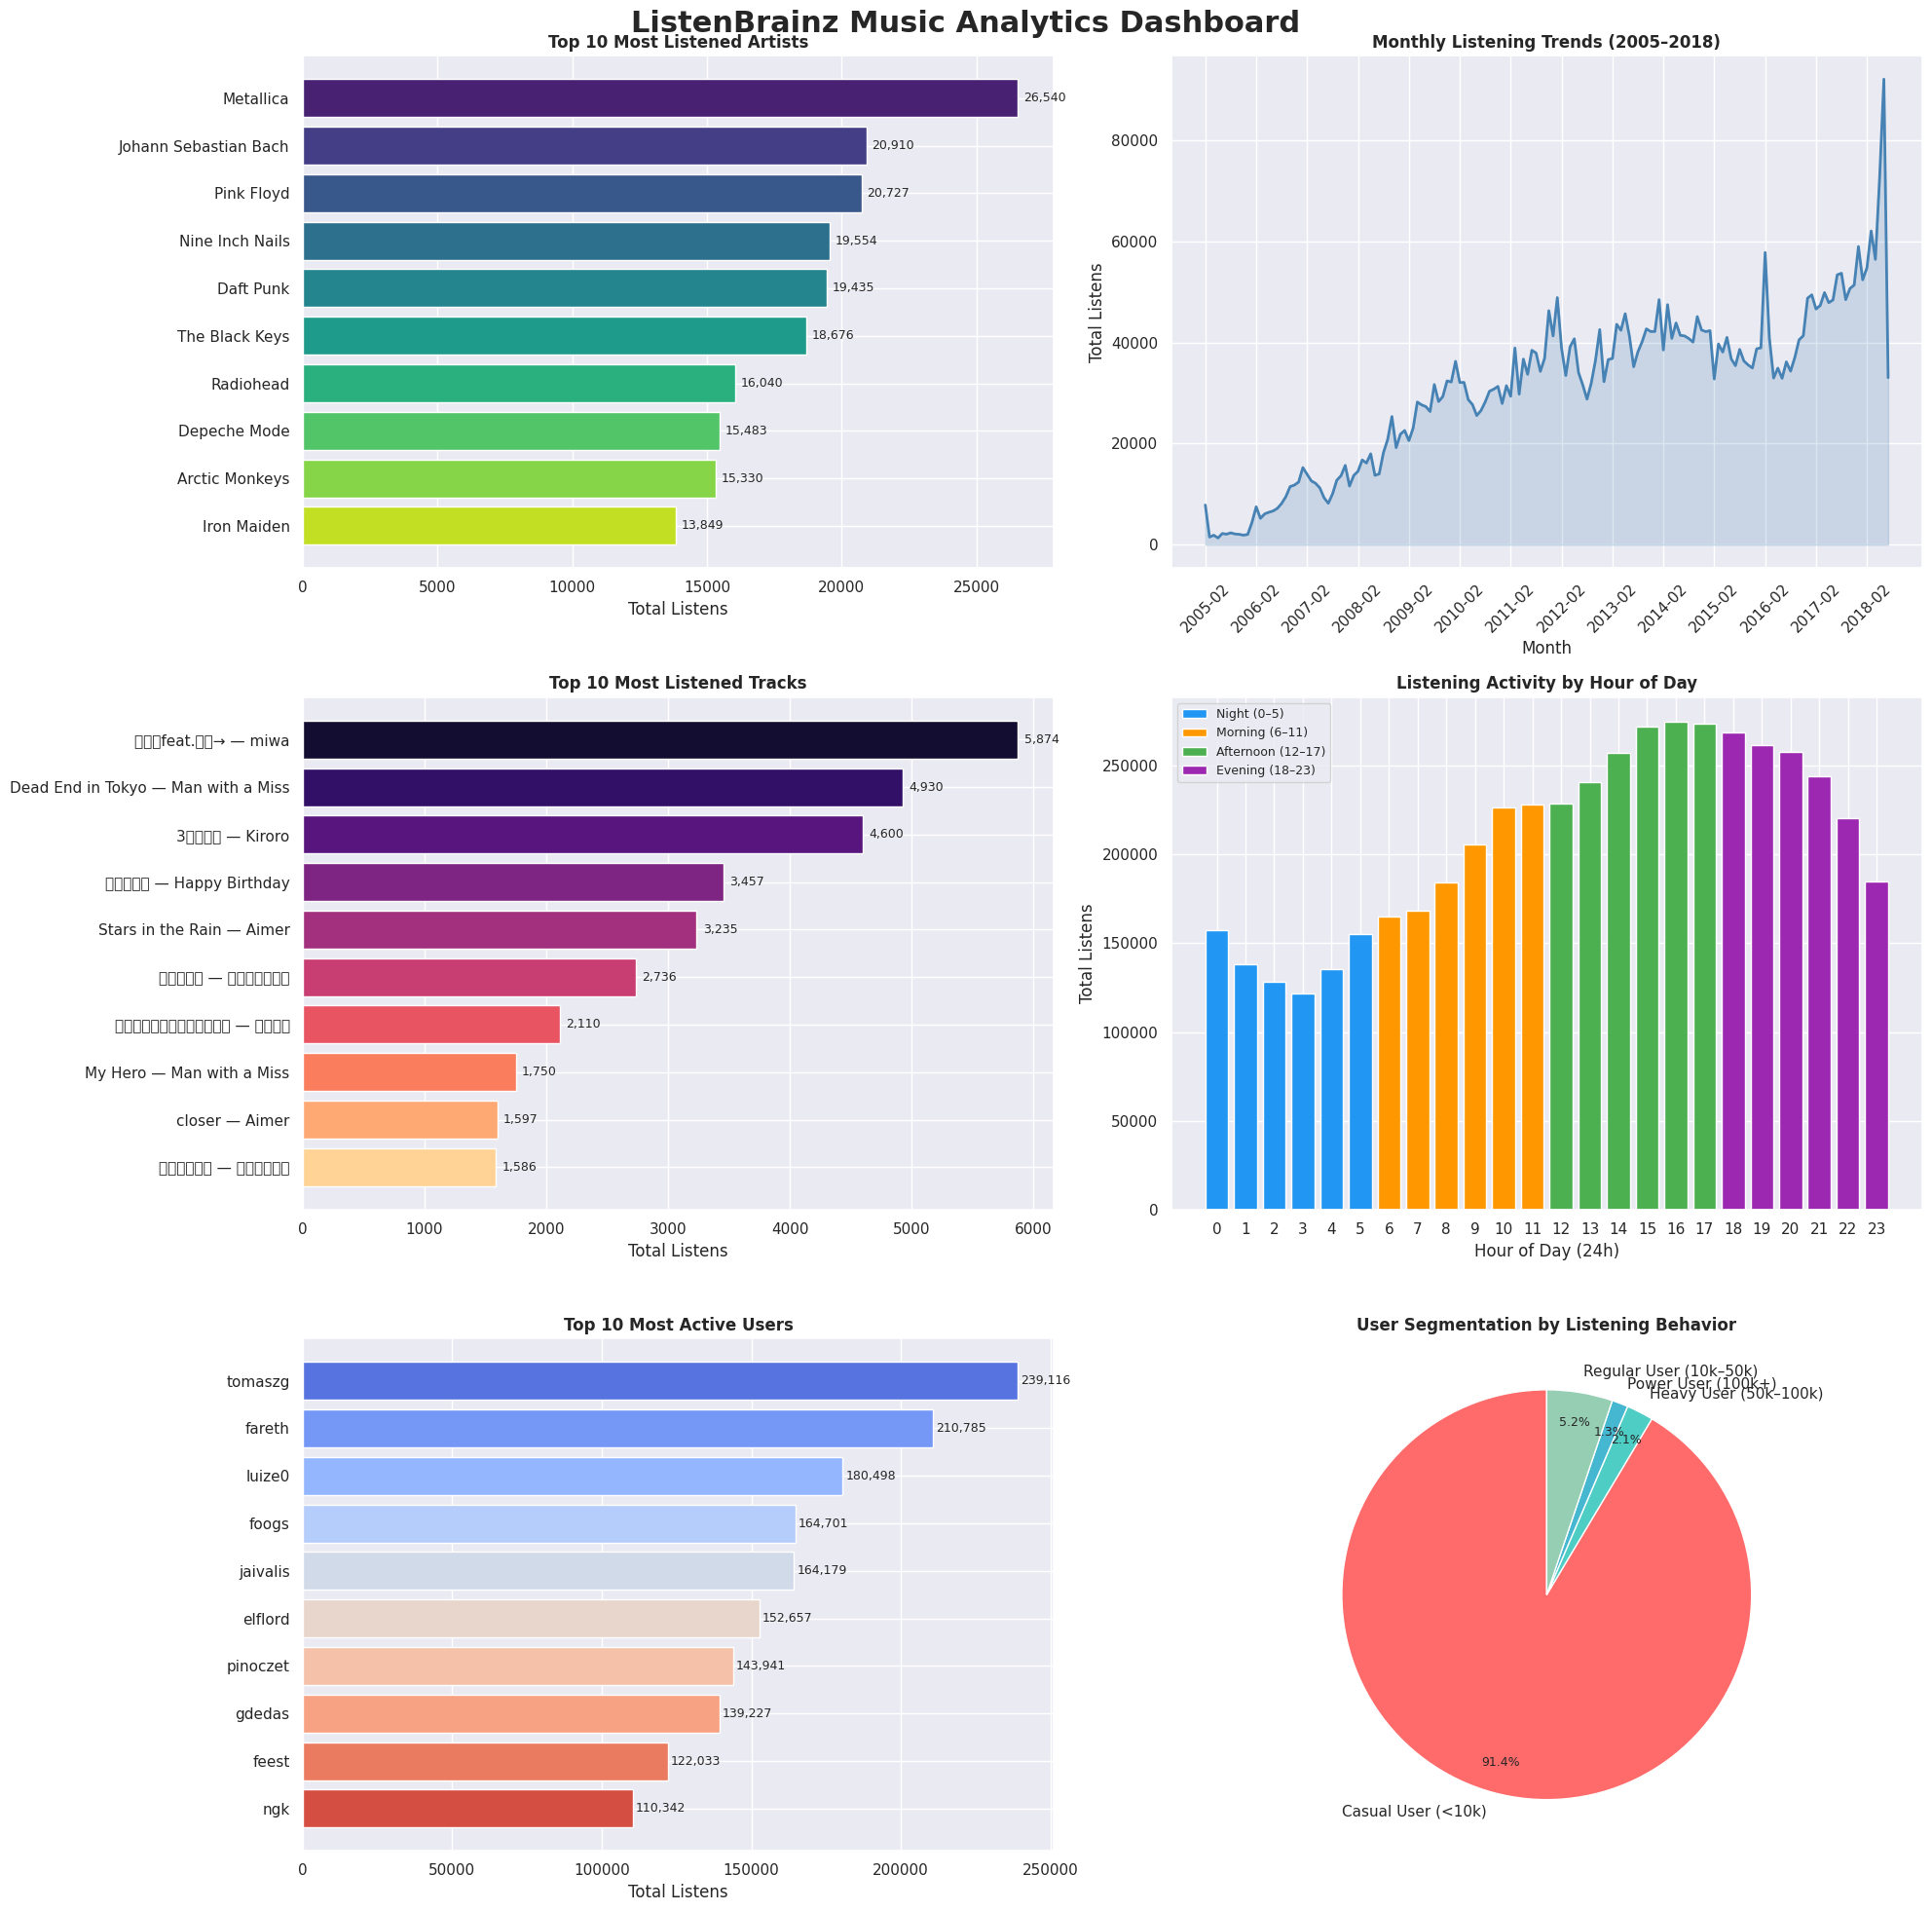

✅ Dashboard saved as listenbrainz_dashboard.png


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(3, 2, figsize=(20, 20))
fig.suptitle('ListenBrainz Music Analytics Dashboard', fontsize=22, fontweight='bold', y=0.98)

# --- Chart 1: Top 10 Artists ---
ax1 = axes[0, 0]
colors1 = sns.color_palette("viridis", len(top_artists))
bars1 = ax1.barh(top_artists['artist_name'], top_artists['total_listens'], color=colors1)
ax1.set_xlabel('Total Listens')
ax1.set_title('Top 10 Most Listened Artists', fontweight='bold')
ax1.invert_yaxis()
for bar, val in zip(bars1, top_artists['total_listens']):
    ax1.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)

# --- Chart 2: Monthly Trends ---
ax2 = axes[0, 1]
monthly_trends['period'] = (monthly_trends['listen_year'].astype(str) + '-' +
                             monthly_trends['listen_month'].astype(str).str.zfill(2))
ax2.plot(monthly_trends['period'], monthly_trends['total_listens'],
         color='steelblue', linewidth=2)
ax2.set_xlabel('Month')
ax2.set_ylabel('Total Listens')
ax2.set_title('Monthly Listening Trends (2005–2018)', fontweight='bold')
ax2.fill_between(range(len(monthly_trends)), monthly_trends['total_listens'], alpha=0.2, color='steelblue')

# show only every 12th label to avoid crowding
tick_positions = range(0, len(monthly_trends), 12)
ax2.set_xticks(list(tick_positions))
ax2.set_xticklabels([monthly_trends['period'].iloc[i] for i in tick_positions], rotation=45)

# --- Chart 3: Top 10 Tracks ---
ax3 = axes[1, 0]
track_labels = top_tracks['track_name'].str[:25] + ' — ' + top_tracks['artist_name'].str[:15]
colors3 = sns.color_palette("magma", len(top_tracks))
bars3 = ax3.barh(track_labels, top_tracks['total_listens'], color=colors3)
ax3.set_xlabel('Total Listens')
ax3.set_title('Top 10 Most Listened Tracks', fontweight='bold')
ax3.invert_yaxis()
for bar, val in zip(bars3, top_tracks['total_listens']):
    ax3.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)

# --- Chart 4: Listening by Hour ---
ax4 = axes[1, 1]
hour_colors = ['#2196F3' if h < 6 else '#FF9800' if h < 12
               else '#4CAF50' if h < 18 else '#9C27B0'
               for h in hourly_trends['listen_hour']]
ax4.bar(hourly_trends['listen_hour'], hourly_trends['total_listens'], color=hour_colors, width=0.8)
ax4.set_xlabel('Hour of Day (24h)')
ax4.set_ylabel('Total Listens')
ax4.set_title('Listening Activity by Hour of Day', fontweight='bold')
ax4.set_xticks(range(0, 24))

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2196F3', label='Night (0–5)'),
    Patch(facecolor='#FF9800', label='Morning (6–11)'),
    Patch(facecolor='#4CAF50', label='Afternoon (12–17)'),
    Patch(facecolor='#9C27B0', label='Evening (18–23)')
]
ax4.legend(handles=legend_elements, fontsize=9)

# --- Chart 5: Most Active Users ---
ax5 = axes[2, 0]
colors5 = sns.color_palette("coolwarm", len(top_users))
bars5 = ax5.barh(top_users['user_name'], top_users['total_listens'], color=colors5)
ax5.set_xlabel('Total Listens')
ax5.set_title('Top 10 Most Active Users', fontweight='bold')
ax5.invert_yaxis()
for bar, val in zip(bars5, top_users['total_listens']):
    ax5.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)

# --- Chart 6: User Segmentation ---
ax6 = axes[2, 1]
query_seg = """
    select
        case
            when count(*) >= 100000 then 'Power User (100k+)'
            when count(*) >= 50000  then 'Heavy User (50k–100k)'
            when count(*) >= 10000  then 'Regular User (10k–50k)'
            else 'Casual User (<10k)'
        end as user_segment,
        count(distinct u.user_name) as user_count
    from `bigdata-proj-496610.listenbrainz_dev.fact_listens` f
    left join `bigdata-proj-496610.listenbrainz_dev.dim_user` u
        on f.user_sk = u.user_sk
    group by u.user_name
"""
user_segments = client.query(query_seg).to_dataframe()
segment_counts = user_segments.groupby('user_segment')['user_count'].sum()

colors6 = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
wedges, texts, autotexts = ax6.pie(
    segment_counts.values,
    labels=segment_counts.index,
    autopct='%1.1f%%',
    colors=colors6,
    startangle=90,
    pctdistance=0.85
)
for text in autotexts:
    text.set_fontsize(9)
ax6.set_title('User Segmentation by Listening Behavior', fontweight='bold')

plt.tight_layout()
plt.savefig('listenbrainz_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved as listenbrainz_dashboard.png")